# Specifying Colors

## Color Formats

<dl>
    <dt style='font-weight:bold;color:green;'>RGB  or RGBA tuple of float values</dt>
    <dd>(0.1, 0.2, 0.5) or (0.1, 0.2, 0.5, 0.3)</dd>
    <dt style='font-weight:bold;color:green;'>Hex RGB or RGBA string</dt>
    <dd>"#0F0F0F" or "#0F0F0F80"</dd>
    <dt style='font-weight:bold;color:green;'>Hex shorthand of duplicate values</dt>
    <dd>"#ABC" as "#AABBCC"</dd>
    <dt style='font-weight:bold;color:green;'>Single character shorthand notation of basic colors</dt>
    <dd>"b" for blue, "g" for green, "r" for red, "k" for black etc</dd>
    <dt style='font-weight:bold;color:green;'>"CN" color spec. C precedes an index into the default property cycle</dt>
    <dd>"C0", "C1" etc</dd>
    <dt style='font-weight:bold;color:green;'>X11/CSS4 color name with no spaces</dt>
    <dd>"aquamarine", "mediumseagreen" etc</dd>
</dl>

## Transparency

(np.float64(-0.2), np.float64(13.0), np.float64(-1.0), np.float64(1.0))

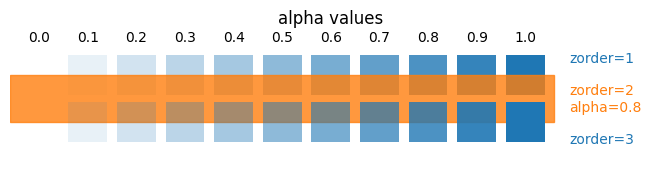

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(6.5, 1.65), layout="constrained")
ax.add_patch(Rectangle((-0.2, -0.35), 11.2, 0.7, color="C1", alpha=0.8))

for i, alpha in enumerate(np.linspace(0, 1, 11)):
    ax.add_patch(Rectangle((i, 0.05), 0.8, 0.6, alpha=alpha, zorder=0))
    ax.text(i + 0.4, 0.85, f"{alpha:.1f}", ha="center")
    ax.add_patch(Rectangle((i, -0.05), 0.8, -0.6, alpha=alpha, zorder=2))

ax.set_xlim(-0.2, 13)
ax.set_ylim(-1, 1)
ax.set_title("alpha values")
ax.text(11.3, 0.6, "zorder=1", va="center", color="C0")
ax.text(11.3, 0, "zorder=2\nalpha=0.8", va="center", color="C1")
ax.text(11.3, -0.6, "zorder=3", va="center", color="C0")
ax.axis("off")

## "CN" Color Selection

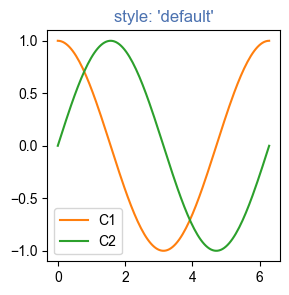

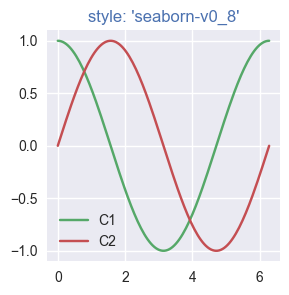

In [3]:
import matplotlib as mpl

th = np.linspace(0, 2 * np.pi, 128)


def demo(sty):
    mpl.style.use(sty)
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.set_title(f"style: {sty!r}", color="C0")
    ax.plot(th, np.cos(th), "C1", label="C1")
    ax.plot(th, np.sin(th), "C2", label="C2")
    ax.legend()


demo("default")
demo("seaborn-v0_8")

## Comparison Between X11/CSS4 and xkcd Colors

# Customized Colorbars Tutorial
## Basic Continuous Colorbar

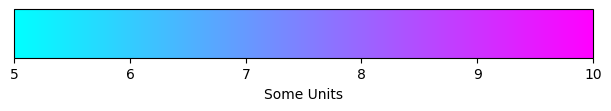

In [4]:
plt.style.use("default")
fig, ax = plt.subplots(figsize=(6, 1), layout="constrained")

# the normalizing object which scales data
norm = mpl.colors.Normalize(vmin=5, vmax=10)
# the colormap used to map normalized values to RGBA colors.
cmap = plt.get_cmap("cool")

fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,  # cax: draw the colorbar into Axes ax
    orientation="horizontal",
    label="Some Units",
)

## Colorbar attached next to a pre-existing axes

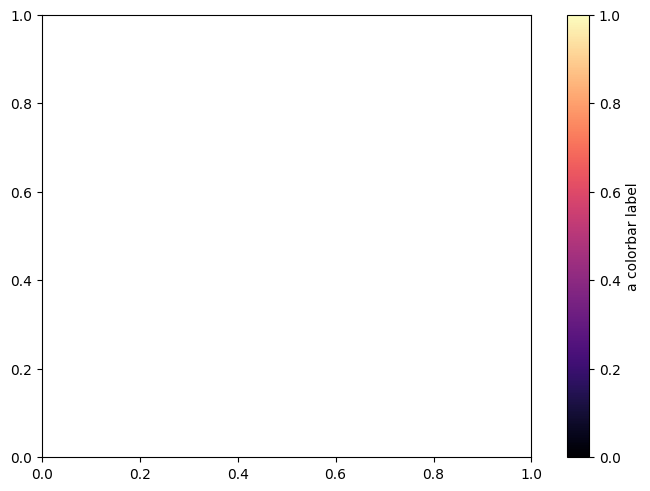

In [5]:
fig, ax = plt.subplots(layout="constrained")

fig.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, 1), cmap="magma"),
    ax=ax,  # ax: display the colorbar next the the Axes ax
    orientation="vertical",
    label="a colorbar label",
)

## Discrete and Extended Colorbar with Continuous Colorscale

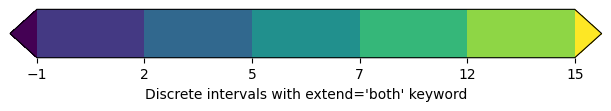

In [6]:
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable

fig, ax = plt.subplots(figsize=(6, 1), layout="constrained")

cmap = plt.get_cmap("viridis")  # magma, cool etc.
bounds = [-1, 2, 5, 7, 12, 15]
norm = BoundaryNorm(bounds, cmap.N, extend="both")

fig.colorbar(
    ScalarMappable(norm, cmap),
    cax=ax,
    orientation="horizontal",
    label="Discrete intervals with extend='both' keyword",
)

## Colorbar with arbitrary colors

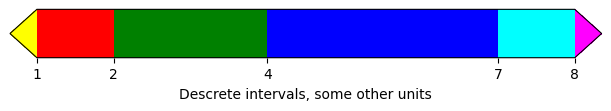

In [7]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.cm import ScalarMappable

fig, ax = plt.subplots(figsize=(6, 1), layout="constrained")

cmap = ListedColormap(["red", "green", "blue", "cyan"]).with_extremes(under="yellow", over="magenta")
bounds = [1, 2, 4, 7, 8]
norm = BoundaryNorm(bounds, cmap.N)

fig.colorbar(
    ScalarMappable(cmap=cmap, norm=norm),
    cax=ax,
    orientation="horizontal",
    extend="both",
    spacing="proportional",
    label="Descrete intervals, some other units",
)

## Colorbar with custom extension lengths

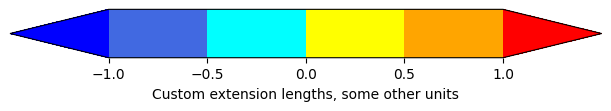

In [8]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.cm import ScalarMappable

fig, ax = plt.subplots(figsize=(6, 1), layout="constrained")

cmap = ListedColormap(["royalblue", "cyan", "yellow", "orange"]).with_extremes(over="red", under="blue")
bounds = [-1.0, -0.5, 0.0, 0.5, 1.0]
norm = BoundaryNorm(bounds, cmap.N)

fig.colorbar(
    ScalarMappable(cmap=cmap, norm=norm),
    cax=ax,
    orientation="horizontal",
    extend="both",
    extendfrac="auto",
    spacing="uniform",
    label="Custom extension lengths, some other units",
)

# Creating Colormaps in Matplotlib

## Getting colormaps and accessing their values

In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import numpy as np

# viridis = plt.colormaps["viridis"].resampled(8)
viridis = plt.get_cmap("viridis").resampled(8)

In [10]:
print(viridis(0.56))

(np.float64(0.122312), np.float64(0.633153), np.float64(0.530398), np.float64(1.0))


### ListedColormap

In [11]:
print("viridis.colors", viridis.colors)
print("\n")
print("viridis(range(8))", viridis(range(8)))
print("\n")
print("viridis(np.linspace(0, 1, 8))", viridis(np.linspace(0, 1, 8)))

viridis.colors [[0.267004 0.004874 0.329415 1.      ]
 [0.275191 0.194905 0.496005 1.      ]
 [0.212395 0.359683 0.55171  1.      ]
 [0.153364 0.497    0.557724 1.      ]
 [0.122312 0.633153 0.530398 1.      ]
 [0.288921 0.758394 0.428426 1.      ]
 [0.626579 0.854645 0.223353 1.      ]
 [0.993248 0.906157 0.143936 1.      ]]


viridis(range(8)) [[0.267004 0.004874 0.329415 1.      ]
 [0.275191 0.194905 0.496005 1.      ]
 [0.212395 0.359683 0.55171  1.      ]
 [0.153364 0.497    0.557724 1.      ]
 [0.122312 0.633153 0.530398 1.      ]
 [0.288921 0.758394 0.428426 1.      ]
 [0.626579 0.854645 0.223353 1.      ]
 [0.993248 0.906157 0.143936 1.      ]]


viridis(np.linspace(0, 1, 8)) [[0.267004 0.004874 0.329415 1.      ]
 [0.275191 0.194905 0.496005 1.      ]
 [0.212395 0.359683 0.55171  1.      ]
 [0.153364 0.497    0.557724 1.      ]
 [0.122312 0.633153 0.530398 1.      ]
 [0.288921 0.758394 0.428426 1.      ]
 [0.626579 0.854645 0.223353 1.      ]
 [0.993248 0.906157 0.143936 1.   

## Creating Listed Colormaps

In [12]:
def plot_examples(colormaps):
    """Helper function to plot data with associated colormap"""
    np.random.seed(19680801)
    data = np.random.randn(30, 30)
    n = len(colormaps)
    fig, axs = plt.subplots(1, n, figsize=(2 * n + 2, 3), layout="constrained", squeeze=False)

    for [ax, cmap] in zip(axs.flat, colormaps):
        psm = ax.pcolormesh(data, cmap=cmap, rasterized=True, vmin=-4, vmax=4)
        fig.colorbar(psm, ax=ax)

    plt.show()

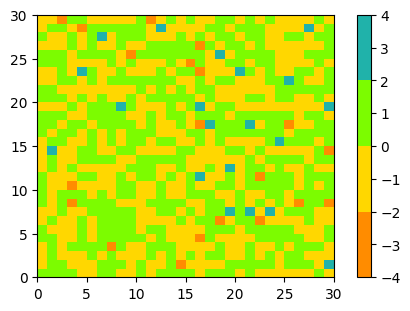

In [13]:
# Create a colormap from a list of names
cmap = ListedColormap(["darkorange", "gold", "lawngreen", "lightseagreen"])
plot_examples([cmap])

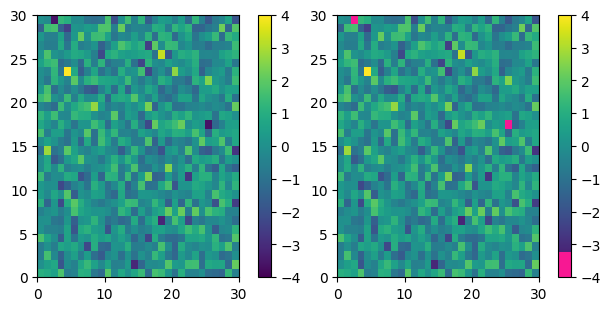

In [14]:
# Make the first 25 entries of a 256-length "viridis" colormap, pink, for some reason!
viridis = plt.get_cmap("viridis").resampled(256)
newcolors = viridis(np.linspace(0, 1, 256))
pink = np.array([248 / 256, 24 / 256, 148 / 256, 1])
newcolors[:25, :] = pink
newcmp = ListedColormap(newcolors)

plot_examples([viridis, newcmp])

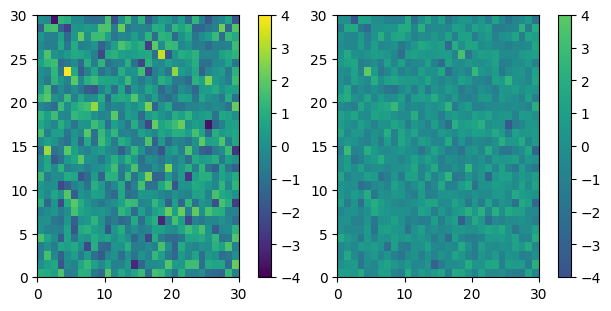

In [15]:
# Reduce the dynamic range of a colormap; here we choose the middle half of the colormap
viridis_big = plt.get_cmap("viridis")
newcmp = ListedColormap(viridis_big(np.linspace(0.25, 0.75, 128)))
plot_examples([viridis, newcmp])

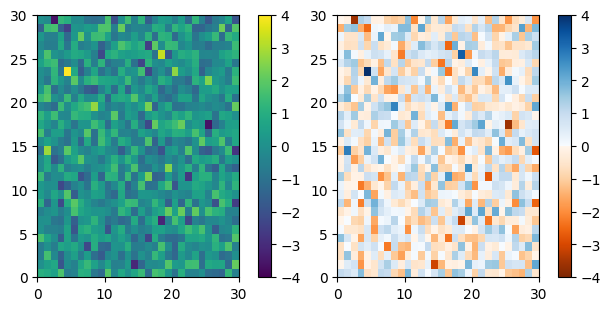

In [16]:
# Concatenate two colormaps
top = plt.get_cmap("Oranges_r").resampled(128)
bottom = plt.get_cmap("Blues").resampled(128)
viridis = plt.get_cmap("viridis")

new_colors = np.vstack(
    (
        top(np.linspace(0, 1, 128)),
        bottom(np.linspace(0, 1, 128)),
    )
)
newcmp = ListedColormap(new_colors, name="OrangeBlue")

plot_examples([viridis, newcmp])

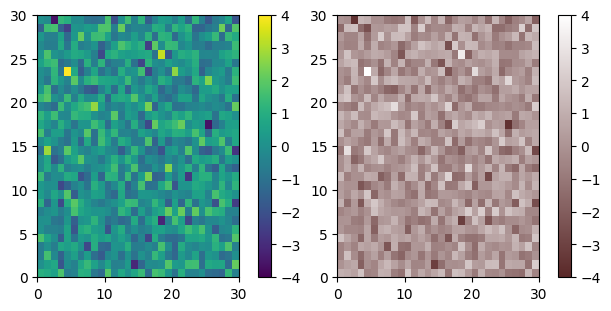

In [17]:
# Create a colormap  that goes from brown(90,40,40) to white(255,255,255)
N = 256
vals = np.ones((N, 4))
vals[:, 0] = np.linspace(90 / 256, 1, N)  # 1st column
vals[:, 1] = np.linspace(40 / 256, 1, N)  # 2nd column
vals[:, 2] = np.linspace(40 / 256, 1, N)  # 3rd column
newcmp = ListedColormap(vals)

plot_examples([viridis, newcmp])

In [18]:
vals

array([[0.3515625 , 0.15625   , 0.15625   , 1.        ],
       [0.35410539, 0.15955882, 0.15955882, 1.        ],
       [0.35664828, 0.16286765, 0.16286765, 1.        ],
       ...,
       [0.99491422, 0.99338235, 0.99338235, 1.        ],
       [0.99745711, 0.99669118, 0.99669118, 1.        ],
       [1.        , 1.        , 1.        , 1.        ]], shape=(256, 4))

## Creating Linear Segmented Colormaps

# Colormap Normalization

Artists that map data to color, pass the arguments`vmin` and `vmax` to construct a **matplotlib.colors.Normalize()** instance, then call it:

In [19]:
from matplotlib.colors import Normalize

norm = Normalize(vmin=-1, vmax=1)
norm(0)

np.float64(0.5)

## Logarithmic

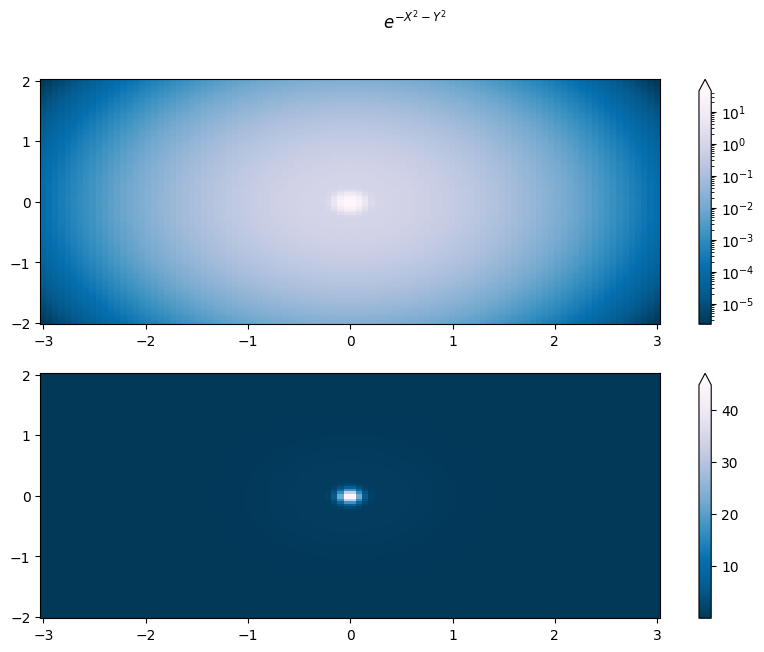

In [20]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cbook as cbook
from matplotlib import _cm
import numpy as np

N = 100
X, Y = np.mgrid[-3 : 3 : complex(0, N), -2 : 2 : complex(0, N)]

Z1 = np.exp(-(X**2) - Y**2)
Z2 = np.exp(-((X * 10) ** 2) - (Y * 10) ** 2)
Z = Z1 + 50 * Z2

fig, ax = plt.subplots(2, 1, figsize=(10, 7))
pcm = ax[0].pcolor(
    X,
    Y,
    Z,
    norm=colors.LogNorm(vmin=Z.min(), vmax=Z.max()),
    cmap="PuBu_r",
    shading="auto",
)
fig.colorbar(pcm, ax=ax[0], extend="max")
pcm = ax[1].pcolor(
    X,
    Y,
    Z,
    cmap="PuBu_r",
    shading="auto",
)
fig.colorbar(pcm, ax=ax[1], extend="max")

fig.suptitle(r"$e^{-X^2-Y^2}$")

plt.show()

## Centered

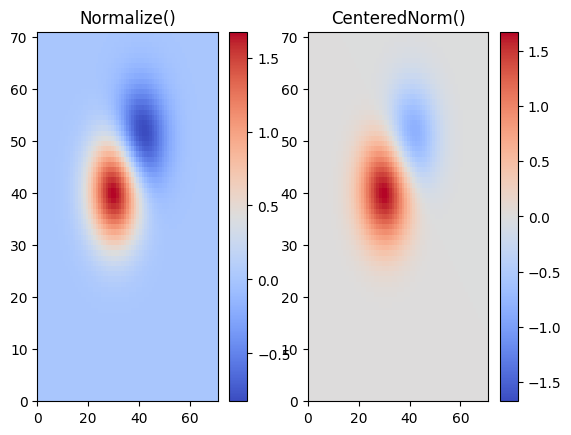

In [21]:
delta = 0.1
x = np.arange(-3.0, 4.001, delta)
y = np.arange(-4.0, 3.001, delta)
X, Y = np.meshgrid(x, y)
Z1 = np.exp(-(X**2) - Y**2)
Z2 = np.exp(-((X - 1) ** 2) - (Y - 1) ** 2)
Z = (0.9 * Z1 - 0.5 * Z2) * 2

# select a divergent colormap
cmap = plt.get_cmap("coolwarm")

fig, (ax1, ax2) = plt.subplots(ncols=2)
pc = ax1.pcolormesh(Z, cmap=cmap)
fig.colorbar(pc, ax=ax1)
ax1.set_title("Normalize()")

pc = ax2.pcolormesh(Z, norm=colors.CenteredNorm(), cmap=cmap)
fig.colorbar(pc, ax=ax2)
ax2.set_title("CenteredNorm()")
plt.show()

## Symmetric Logarithmic
### Logarithmic

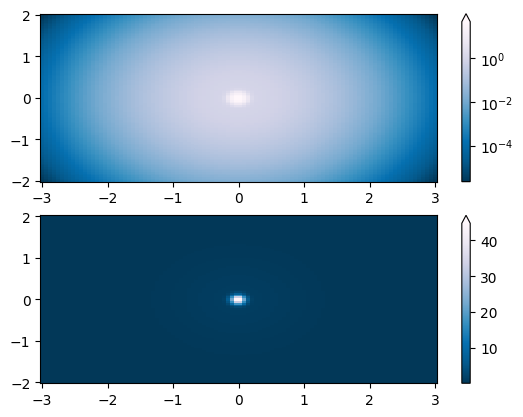

In [22]:
N = 100
X, Y = np.mgrid[-3 : 3 : complex(0, N), -2 : 2 : complex(0, N)]

# A low hump with a spike coming out of the top right. Needs to have
# z/color axis on a log scale, so we see both hump and spike. A linear
# scale only shows the spike.
Z1 = np.exp(-(X**2) - (Y**2))
Z2 = np.exp(-((X * 10) ** 2) - (Y * 10) ** 2)
Z = Z1 + 50 * Z2

fig, ax = plt.subplots(2, 1)

pcm = ax[0].pcolor(
    X,
    Y,
    Z,
    norm=colors.LogNorm(vmin=Z.min(), vmax=Z.max()),
    cmap="PuBu_r",
    shading="auto",
)
fig.colorbar(pcm, ax=ax[0], extend="max")

pcm = ax[1].pcolor(
    X,
    Y,
    Z,
    cmap="PuBu_r",
    shading="auto",
)
fig.colorbar(pcm, ax=ax[1], extend="max")

plt.show()

### Power-law

Text(0.5, 1.0, 'Normalize()')

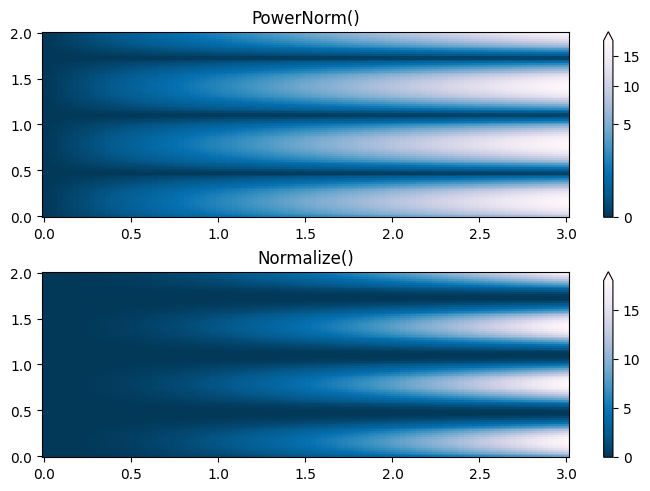

In [23]:
N = 100
X, Y = np.mgrid[0 : 3 : complex(0, N), 0 : 2 : complex(0, N)]
Z1 = (1 + np.sin(Y * 10.0)) * X**2

fig, ax = plt.subplots(2, 1, layout="constrained")

pcm = ax[0].pcolormesh(X, Y, Z1, norm=colors.PowerNorm(gamma=0.5), cmap="PuBu_r", shading="auto")
fig.colorbar(pcm, ax=ax[0], extend="max")
ax[0].set_title("PowerNorm()")

pcm = ax[1].pcolormesh(X, Y, Z1, cmap="PuBu_r", shading="auto")
fig.colorbar(pcm, ax=ax[1], extend="max")
ax[1].set_title("Normalize()")

# Choosing Colormaps in Matplotlib
Here's a list of all registered colormaps.

In [24]:
from matplotlib import colormaps

list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

## Classes of Colormaps
Show the range of each colormap

In [25]:
from colorspacious import cspace_converter

cmaps = {}

gradient = np.linspace(0, 1, 256)
gradient = np.vstack((gradient, gradient))


def plot_color_gradients(category: str, cmap_list: list):
    # create figure and adjust figure height to number of colormaps
    nrows = len(cmap_list)
    figh = 0.35 + 0.15 + (nrows + (nrows - 1) * 0.1) * 0.22
    fig, axs = plt.subplots(nrows=nrows + 1, figsize=(6.4, figh))
    fig.subplots_adjust(top=1 - 0.35 / figh, bottom=0.15 / figh, left=0.2, right=0.99)
    axs[0].set_title(f"{category} colormaps", fontsize=14)

    for ax, name in zip(axs, cmap_list):
        ax.imshow(gradient, aspect="auto", cmap=mpl.colormaps[name])
        ax.text(-0.01, 0.5, name, va="center", ha="right", fontsize=10, transform=ax.transAxes)

        # Turn off all ticks & spines, not just the ones with colormaps
        for ax in axs:
            ax.set_axis_off()

        # Save colormap list for latr
        cmaps[category] = cmap_list

## Sequential

Change in lightness and often saturation of color incrementally, often using a single hue; should be used for representing **information that has ordering**.

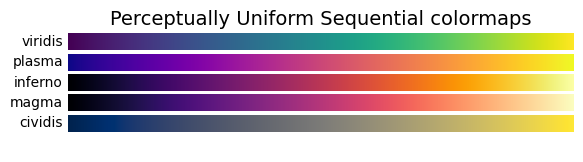

In [26]:
plot_color_gradients(
    "Perceptually Uniform Sequential",
    [
        "viridis",
        "plasma",
        "inferno",
        "magma",
        "cividis",
    ],
)

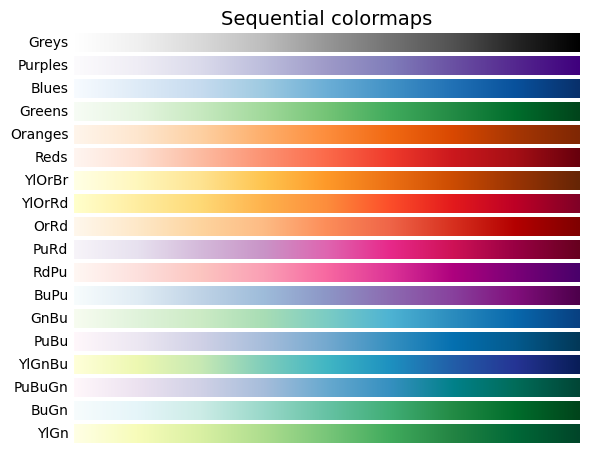

In [29]:
plot_color_gradients(
    "Sequential",
    [
        "Greys",
        "Purples",
        "Blues",
        "Greens",
        "Oranges",
        "Reds",
        "YlOrBr",
        "YlOrRd",
        "OrRd",
        "PuRd",
        "RdPu",
        "BuPu",
        "GnBu",
        "PuBu",
        "YlGnBu",
        "PuBuGn",
        "BuGn",
        "YlGn",
    ],
)

## Sequential2

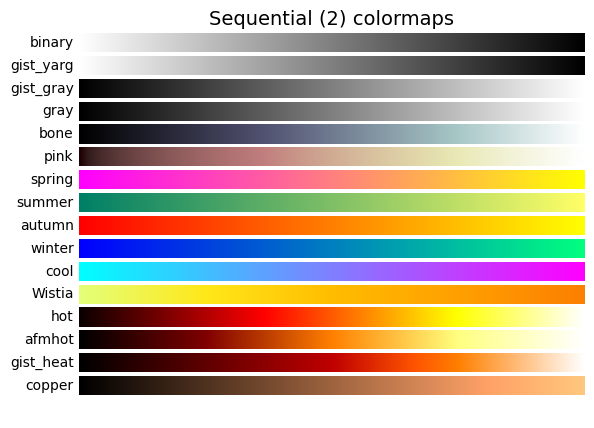

In [30]:
plot_color_gradients(
    "Sequential (2)",
    [
        "binary",
        "gist_yarg",
        "gist_gray",
        "gray",
        "bone",
        "pink",
        "spring",
        "summer",
        "autumn",
        "winter",
        "cool",
        "Wistia",
        "hot",
        "afmhot",
        "gist_heat",
        "copper",
    ],
)

## Diverging

Change in lightness and possibly saturation of two different colors that meet in the middle at an unsaturated color; should be used when the information being plotted **has a critical middle value**, such as topography or when the data deviates around zero.

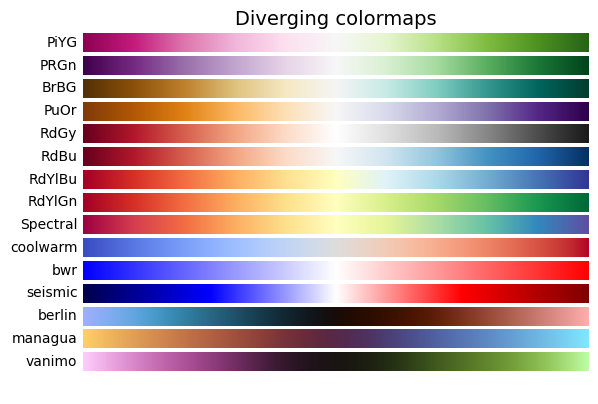

In [32]:
plot_color_gradients(
    "Diverging",
    [
        "PiYG",
        "PRGn",
        "BrBG",
        "PuOr",
        "RdGy",
        "RdBu",
        "RdYlBu",
        "RdYlGn",
        "Spectral",
        "coolwarm",
        "bwr",
        "seismic",
        "berlin",
        "managua",
        "vanimo",
    ],
)

## Cyclic

Change in lightness of two different colors that meet in the middle and beginning/end at an unsaturated color; should be used for values that **wrap around at the endpoints**, such as phase angle, wind direction, or time of day.

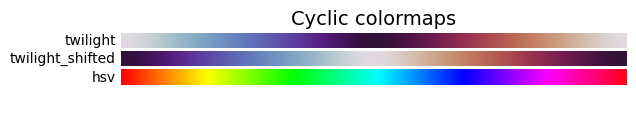

In [33]:
plot_color_gradients("Cyclic", ["twilight", "twilight_shifted", "hsv"])

## Qualitative

Often are miscellaneous colors; should be used to represent information which doesn't have ordering or perceptions.

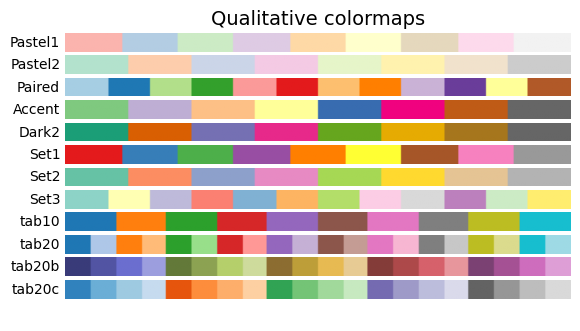

In [34]:
plot_color_gradients(
    "Qualitative",
    ["Pastel1", "Pastel2", "Paired", "Accent", "Dark2", "Set1", "Set2", "Set3", "tab10", "tab20", "tab20b", "tab20c"],
)

## Miscellaneous

# Choosing Colormaps in Matplotlib